## Hard-core sampling w Gibbs sampler

Here is a implementation of Gibbs sampler algorithm for the hard-core problem.

In [35]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Create grid for particles

In [12]:
# Set K value for grid size (kxk) suggested 3<=K<=20
K_list = [3, 5, 10, 15, 20]

def create_k_matrix(K):
    # Create a kxk matrix initialized with no particles (you can actually initialize in whichever way you would like lol)
    initial_grid = np.zeros((K, K), dtype=int)
    initial_grid_2 = np.ones((K, K), dtype=int)

    return initial_grid, initial_grid_2

initial_grid, initial_grid_2 = create_k_matrix(K_list[2])

print(f"Created {K_list[2]}x{K_list[2]} grid:")
print(initial_grid)



Created 10x10 grid:
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


### Gibbs random sampler

In [16]:
def run_gibbs_random(grid, K):
    """Move from X_{n} state to X_{n+1} using Gibbs random sampler."""
    # First we select a random vertex on our grid
    i = random.randint(0, K-1)
    j = random.randint(0, K-1)

    # Sample another value for vertex given the other vertex
    # Check if neighbor vertex are 0 (for possible particle in factible grid)
    # Boundary cases
    neighbors_empty = True  # Start assuming neighbors are empty
    
    # Check top neighbor (only if not at top boundary)
    if i > 0 and grid[i-1, j] == 1:
        neighbors_empty = False
    
    # Check bottom neighbor (only if not at bottom boundary)
    if i < K-1 and grid[i+1, j] == 1:
        neighbors_empty = False
    
    # Check left neighbor (only if not at left boundary)
    if j > 0 and grid[i, j-1] == 1:
        neighbors_empty = False
    
    # Check right neighbor (only if not at right boundary)
    if j < K-1 and grid[i, j+1] == 1:
        neighbors_empty = False
    
    if neighbors_empty:
        coin_flipped = random.randint(0,1) # One for heads, zero for tails 
        if coin_flipped == 1:
            grid[i, j] = 1 # Put particle
        else:
            grid[i,j] = 0 # Remove particle
    else:
        grid[i,j] = 0 # If neighbors have particles force no particle in vertex

    return grid
    

### Gibbs sampler w order

In [17]:
def run_gibbs_order(grid, K, i, j):
    """Move from X_{n} state to X{n+1} using Gibbs sampler with order (for faster convergence)."""
    # Check if neighbor vertex are 0 (for possible particle in factible grid)
    # Boundary cases
    neighbors_empty = True  # Start assuming neighbors are empty
    
    # Check top neighbor (only if not at top boundary)
    if i > 0 and grid[i-1, j] == 1:
        neighbors_empty = False
    
    # Check bottom neighbor (only if not at bottom boundary)
    if i < K-1 and grid[i+1, j] == 1:
        neighbors_empty = False
    
    # Check left neighbor (only if not at left boundary)
    if j > 0 and grid[i, j-1] == 1:
        neighbors_empty = False
    
    # Check right neighbor (only if not at right boundary)
    if j < K-1 and grid[i, j+1] == 1:
        neighbors_empty = False
    
    if neighbors_empty:
        coin_flipped = random.randint(0,1) # One for heads, zero for tails 
        if coin_flipped == 1:
            grid[i, j] = 1 # Put particle
        else:
            grid[i,j] = 0 # Remove particle
    else:
        grid[i,j] = 0 # If neighbors have particles force no particle in vertex
    # We pass every vertex of grid in order
    if i == K-1:
        if j == K-1:
            # If we changed last column, last row, start in the beginning of the grid
            i = 0
            j = 0
        else:
            j += 1
    else:
        if j == K-1:
            # If we changed last column, i row, change row and j = 0
            i += 1
            j = 0
        else:
            j += 1
    
    return grid, i, j


### Run Gibbs sampler

In [29]:
final_time = 100001
chain_times = [500, 5000, 10000, 10001, 10002, 100000]

# Run Gibbs random sampler
def get_gibbs_samples_random(chain_times):
    final_grids = []
    for k in K_list:
        print(f"For K={k} we have:")
        updated_grid, updated_grid_2 = create_k_matrix(k)
        for t in range(final_time):
            updated_grid = run_gibbs_random(updated_grid, k)
            if t in chain_times:
                final_grids.append(updated_grid)
                print(f"X_{t} grid:\n{updated_grid}")
    
    return final_grids

x = get_gibbs_samples_random(chain_times)
            

For K=3 we have:
X_500 grid:
[[1 0 1]
 [0 0 0]
 [0 0 1]]
X_5000 grid:
[[0 0 1]
 [1 0 0]
 [0 0 0]]
X_10000 grid:
[[0 1 0]
 [0 0 0]
 [0 0 0]]
X_10001 grid:
[[0 1 0]
 [0 0 0]
 [0 0 0]]
X_10002 grid:
[[0 1 0]
 [0 0 0]
 [0 1 0]]
X_100000 grid:
[[0 1 0]
 [1 0 1]
 [0 1 0]]
For K=5 we have:
X_500 grid:
[[0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 1]
 [0 1 0 1 0]
 [0 0 0 0 1]]
X_5000 grid:
[[0 1 0 0 0]
 [1 0 1 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 1 0 0 0]]
X_10000 grid:
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 1 0]]
X_10001 grid:
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 1 0]]
X_10002 grid:
[[0 0 0 0 0]
 [0 0 0 0 1]
 [0 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 1 0]]
X_100000 grid:
[[1 0 0 0 0]
 [0 0 1 0 1]
 [0 1 0 0 0]
 [0 0 0 0 1]
 [0 1 0 0 0]]
For K=10 we have:
X_500 grid:
[[0 0 1 0 0 0 0 0 1 0]
 [0 0 0 0 0 1 0 1 0 0]
 [1 0 0 0 1 0 0 0 0 0]
 [0 0 1 0 0 1 0 0 1 0]
 [0 0 0 1 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 1 0 1 0 0 0]
 [1 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1]
 

In [30]:
# Run gibbs w order sampler
chain_times = [500, 5000, 10000, 10001, 10002, 100000]
i = 0
j = 0
def get_gibbs_samples_order(chain_times, i, j):
    final_grids = []
    for k in K_list:
        print(f"For K={k} we have:")
        updated_grid, updated_grid_2 = create_k_matrix(k)
        for t in range(final_time):
            updated_grid, i, j = run_gibbs_order(updated_grid, k, i, j)
            if t in chain_times:
                final_grids.append(updated_grid)
                print(f"X_{t} grid:\n{updated_grid}")

    return final_grids

x = get_gibbs_samples_order(chain_times, i, j)
        

For K=3 we have:
X_500 grid:
[[0 0 0]
 [0 0 1]
 [0 0 0]]
X_5000 grid:
[[0 1 0]
 [1 0 0]
 [0 0 0]]
X_10000 grid:
[[0 1 0]
 [0 0 1]
 [0 0 0]]
X_10001 grid:
[[0 1 0]
 [0 0 1]
 [0 0 0]]
X_10002 grid:
[[0 1 0]
 [0 0 1]
 [0 0 0]]
X_100000 grid:
[[0 0 0]
 [0 0 0]
 [0 0 1]]
For K=5 we have:
X_500 grid:
[[0 0 1 0 0]
 [1 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 1]
 [0 0 0 1 0]]
X_5000 grid:
[[0 0 0 0 0]
 [1 0 0 0 1]
 [0 0 0 1 0]
 [0 1 0 0 0]
 [1 0 0 1 0]]
X_10000 grid:
[[1 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]
X_10001 grid:
[[1 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]
X_10002 grid:
[[1 0 1 0 1]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 0 1 0]
 [0 0 0 0 0]]
X_100000 grid:
[[1 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 1 0]
 [1 0 1 0 1]
 [0 0 0 0 0]]
For K=10 we have:
X_500 grid:
[[0 1 0 1 0 0 0 1 0 0]
 [1 0 1 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 1 0]
 [1 0 1 0 0 1 0 0 0 1]
 [0 0 0 0 1 0 0 0 0 0]
 [1 0 0 1 0 0 1 0 0 0]
 

## Hard-core particle estimation

Using the samples made in the past code we will make a histogram of number of particles for different chain times.

In [31]:
def count_particles(grid) -> int:
    """Return the number of particles (cells equal to 1) in the grid."""
    arr = np.asarray(grid)
    return int(np.count_nonzero(arr == 1))

In [33]:
def compute_mean_particles_ordered(runs: int, K_list, chain_times, final_time: int):
    """Return {K: {t: mean_num_particles}} across `runs` for ordered Gibbs."""
    means_by_k = {}
    for K in K_list:
        # accumulator: t -> list of counts
        counts_per_t = {t: [] for t in chain_times}
        for _ in range(runs):
            grid, _grid_ones = create_k_matrix(K)
            i, j = 0, 0
            for step in range(final_time):
                grid, i, j = run_gibbs_order(grid, K, i, j)
                if step in counts_per_t:
                    counts_per_t[step].append(count_particles(grid))
        # convert to means
        means_by_k[K] = {t: float(np.mean(counts)) if counts else 0.0
                         for t, counts in counts_per_t.items()}
    return means_by_k


def plot_mean_particles_hist(means_by_k):
    """Plot bar charts of mean particles at each chain time for every K."""
    # Determine chain_times order from the first K entry
    sample_K = next(iter(means_by_k))
    chain_times_sorted = sorted(means_by_k[sample_K].keys())

    num_K = len(means_by_k)
    cols = 2
    rows = (num_K + cols - 1) // cols
    plt.figure(figsize=(6 * cols, 3.5 * rows))

    for idx, (K, means_dict) in enumerate(sorted(means_by_k.items())):
        plt.subplot(rows, cols, idx + 1)
        values = [means_dict[t] for t in chain_times_sorted]
        plt.bar([str(t) for t in chain_times_sorted], values, color="#4C78A8")
        plt.title(f"K={K} mean particles by chain time")
        plt.xlabel("chain time")
        plt.ylabel("mean # particles")
        plt.tight_layout()

    plt.show()


Mean #particles by K and chain time:
K=3: {500: 1.8, 5000: 2.5, 10000: 2.6, 10001: 2.7, 10002: 2.9, 100000: 2.3}
K=5: {500: 6.9, 5000: 6.5, 10000: 6.9, 10001: 6.9, 10002: 6.9, 100000: 5.7}
K=10: {500: 23.1, 5000: 24.1, 10000: 22.0, 10001: 22.4, 10002: 22.3, 100000: 23.4}
K=15: {500: 50.2, 5000: 52.3, 10000: 52.6, 10001: 52.4, 10002: 52.4, 100000: 54.8}
K=20: {500: 104.1, 5000: 95.2, 10000: 92.7, 10001: 92.7, 10002: 92.7, 100000: 92.8}


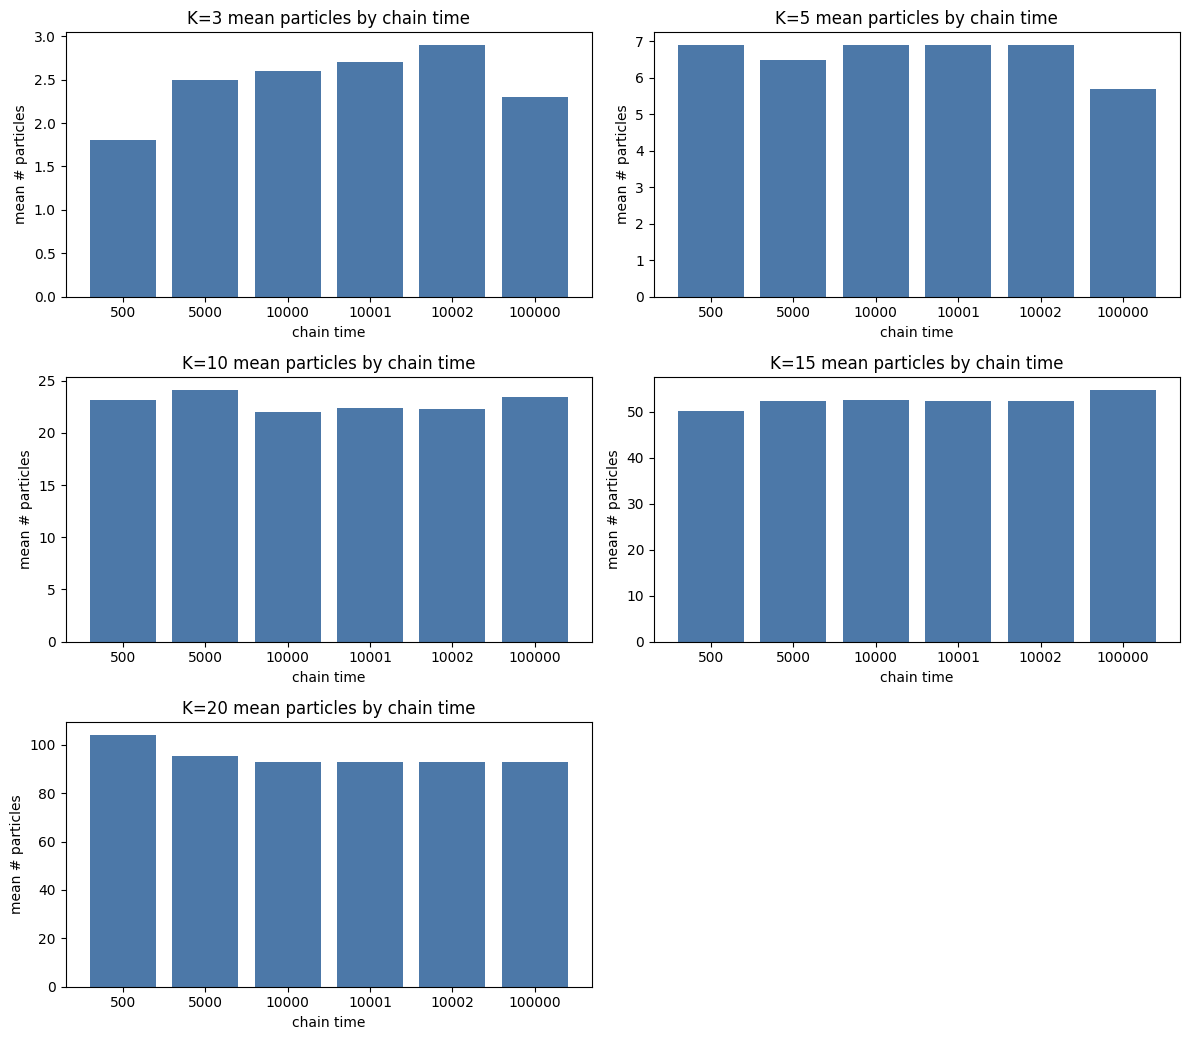

In [36]:
# Configure parameters and run aggregation
runs = 10  # number of independent runs
chain_times = [500, 5000, 10000, 10001, 10002, 100000]
final_time = 100001

means_by_k = compute_mean_particles_ordered(runs, K_list, chain_times, final_time)
print("Mean #particles by K and chain time:")
for K in sorted(means_by_k):
    print(f"K={K}:", {t: round(means_by_k[K][t], 2) for t in sorted(means_by_k[K])})

plot_mean_particles_hist(means_by_k)
